<a href="https://colab.research.google.com/github/akubiszyn/Lies_detector/blob/main/Lie_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Preparations


*   imports
*   loading device
*   connecting with google drive



In [ ]:
!pip install mtcnn

In [ ]:
!pip install pytorch_metric_learning

In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import zipfile
import pickle
import random
from mtcnn import MTCNN
import cv2
import csv
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
# Torch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset
import torch.utils.data as data
import torch.nn.functional as F
import torch.nn.init as init
import torch.optim as optim
# Torchvision
import torchvision
from torchvision.datasets import FashionMNIST
from torchvision import transforms
from torchvision import datasets
from torchvision.io import read_video

from pytorch_metric_learning.losses import TripletMarginLoss
from pytorch_metric_learning.miners import MultiSimilarityMiner
from pytorch_metric_learning.losses import CrossBatchMemory
from sklearn.manifold import TSNE
import seaborn as sns
from contextlib import contextmanager
import contextlib
from google.colab.patches import cv2_imshow
from collections import Counter



In [ ]:
!pip install gdown
import gdown

gdown.download_folder("https://drive.google.com/drive/folders/14E_2V_McrgPzaHOWN2sJxkGdd_IMJA7j?usp=sharing", quiet=False)


Retrieving folder contents


Retrieving folder 11W3eOt6GAW6IzVlDR7BC6Z-jwPrPdwfn experiments
Retrieving folder 1Bj26LdE2EJ7nq0KPqmLlWSFIzVLgHU-S feature_vectors
Processing file 1mPVtML86kdSEBwQVj4CHp8kRd-8Mbqpc miami.zip
Processing file 1EeaDBxs5KUL3FGPPOxAV5Y9RQ-3Qlb0d real-life-trial-data.zip
Retrieving folder 1scDoYXa35HYlVTbuV2sc9a8jcoetT7_U models
Processing file 109t5M0dIOGkYwjk7aOqGKDc667WW1_i6 ModelCNN.pth
Processing file 11YKiFX54rG7z98IXEyGcwb9rM7hRUCIT ModelGRU.pth
Processing file 1BFSk7C47tPI-rruPDGWjsN9zqve_ih2Z RealLifeDeceptionDetection.2016.zip
Processing file 1TfLMNE-4FxAEBkwpkZUzmRERi3peYyRI Videos.zip


Retrieving folder contents completed
Building directory structure
Building directory structure completed
 20%|██        | 758M/3.78G [00:25<00:45, 67.0MB/s]Downloading...
From (original): https://drive.google.com/uc?id=1mPVtML86kdSEBwQVj4CHp8kRd-8Mbqpc
From (redirected): https://drive.google.com/uc?id=1mPVtML86kdSEBwQVj4CHp8kRd-8Mbqpc&confirm=t&uuid=1dc081ef-8fc5-4e10-a585-be20e4170608
To: /content/deception_detection/feature_vectors/miami.zip

  0%|          | 0.00/3.78G [00:00<?, ?B/s]
  0%|          | 6.82M/3.78G [00:00<04:26, 14.2MB/s]
  1%|          | 35.1M/3.78G [00:00<00:49, 75.6MB/s]
  2%|▏         | 58.7M/3.78G [00:01<01:01, 60.2MB/s]
  2%|▏         | 84.9M/3.78G [00:01<00:40, 91.4MB/s]
  3%|▎         | 114M/3.78G [00:01<00:28, 128MB/s]  
  4%|▎         | 136M/3.78G [00:02<01:11, 50.9MB/s]
  4%|▍         | 164M/3.78G [00:02<00:49, 72.5MB/s]
  5%|▌         | 190M/3.78G [00:02<00:37, 94.5MB/s]
  6%|▌         | 215M/3.78G [00:02<00:30, 117MB/s] 
  6%|▋         | 240M/3.78G [00:02

['/content/deception_detection/feature_vectors/miami.zip',
 '/content/deception_detection/feature_vectors/real-life-trial-data.zip',
 '/content/deception_detection/models/ModelCNN.pth',
 '/content/deception_detection/models/ModelGRU.pth',
 '/content/deception_detection/RealLifeDeceptionDetection.2016.zip',
 '/content/deception_detection/Videos.zip']

In [ ]:
# device = torch.device('cpu')
device = torch.device('cuda')
print(device)

DEBUG = False

In [ ]:
# try:
#     from google.colab import drive
#     drive.mount('/content/drive')

#     file_path = '/content/drive/My Drive/ssne/deception_detection/RealLifeDeceptionDetection.2016.zip'

#     miami_path = '/content/drive/My Drive/ssne/deception_detection/Videos.zip'


#     print('Successfully loaded from Google Drive')

# except Exception:

#     file_path = 'RealLifeDeceptionDetection.2016.zip'
#     print('Failed to load from Google Drive')

In [ ]:
trial_video_path = './deception_detection/RealLifeDeceptionDetection.2016.zip'
miami_video_path = './deception_detection/Videos.zip'

trial_features_path = './deception_detection/feature_vectors/real-life-trial-data.zip'
miami_features_path = './deception_detection/feature_vectors/miami.zip'

unzipped_trial_video_path = './deception_detection/Real-life_Deception_Detection_2016'
unzipped_miami_video_path = './deception_detection/Videos'

unzipped_trial_features_path = './deception_detection/feature_vectors_zipped/real-life-trial-data'
unzipped_miami_features_path = './deception_detection/feature_vectors_zipped/miami'




In [ ]:
if not os.path.exists(unzipped_trial_video_path):
    with zipfile.ZipFile(trial_video_path, 'r') as zip_ref:
        zip_ref.extractall(unzipped_trial_video_path)
if not os.path.exists(unzipped_miami_video_path):
    with zipfile.ZipFile(miami_video_path, 'r') as zip_ref:
        zip_ref.extractall(unzipped_miami_video_path)
if not os.path.exists(unzipped_trial_features_path):
    with zipfile.ZipFile(trial_features_path, 'r') as zip_ref:
        zip_ref.extractall(unzipped_trial_features_path)
if not os.path.exists(unzipped_miami_features_path):
    with zipfile.ZipFile(miami_features_path, 'r') as zip_ref:
        zip_ref.extractall(unzipped_miami_features_path)

In [ ]:
# !zip -r real-life-trial-data.zip /content/drive/MyDrive/ssne/deception_detection/feature_vectors/real-life-trial-data

# CNN Model

In [ ]:
class CNN(nn.Module):
    def __init__(self, dropout):
        super().__init__()
        c_hid = 7
        act_fn = nn.LeakyReLU(0.01)
        self.conv_1 = nn.Conv2d(1, c_hid, kernel_size=7, padding=1) #48x48 => 44x44
        self.conv_2 = nn.Conv2d(c_hid,4*c_hid, kernel_size=7, padding=1) #44x44 => 40x40
        self.conv_3 = nn.Conv2d(4*c_hid, 8*c_hid, kernel_size=7, padding=1) #20x20 => 16x16
        self.conv_4 = nn.Conv2d(8*c_hid, 12*c_hid, kernel_size=7, padding=1) #16x16 => 12x12

        self.linear_1 = nn.Linear(12096, 4320)
        self.linear_2 = nn.Linear(4320, 1152)
        self.linear_3 = nn.Linear(1152, 512)
        self.linear_4 = nn.Linear(512, 7)

        self.first_skip_conv = nn.Conv2d(1, c_hid, kernel_size=5)

        self.net_conv_1_2= nn.Sequential(

            self.conv_1,
            nn.BatchNorm2d(c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_2,
            nn.BatchNorm2d(4*c_hid),
            nn.Dropout(dropout),
            act_fn,

        )
        self.net_conv_3_4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=2, stride=2),

            self.conv_3,
            nn.BatchNorm2d(8*c_hid),
            nn.Dropout(dropout),
            act_fn,
            self.conv_4,
            nn.BatchNorm2d(12*c_hid),
            nn.Dropout(dropout),
            act_fn
        )

        self.linear_net = nn.Sequential(

            nn.Flatten(),

            self.linear_1,
            nn.BatchNorm1d(4320),
            act_fn,
            nn.Dropout(dropout),

            self.linear_2,
            nn.BatchNorm1d(1152),
            act_fn,
            nn.Dropout(dropout),

            self.linear_3,
            nn.BatchNorm1d(512),
            act_fn,
            nn.Dropout(dropout),

            self.linear_4,
            nn.Softmax(dim=1)
        )

        # Inicjalizacja wag
        for layer in [self.conv_1, self.conv_2, self.conv_3, self.conv_4]:
            init.xavier_normal_(layer.weight)

        for layer in [self.linear_1, self.linear_2, self.linear_3, self.linear_4]:
            init.xavier_normal_(layer.weight)

    def conv_layers(self, x):
        features_after_2 = self.net_conv_1_2(x)
        # first_skip_connection = self.first_skip_conv(features_after_2)
        features_after_4 = self.net_conv_3_4(features_after_2) #+ first_skip_connection
        return features_after_4


    def forward(self, x):
        return self.linear_net(self.conv_layers(x))

    def extract_features(self, x):
        features = self.conv_layers(x)
        return features.view(features.size(0), -1)

In [ ]:
CNN_model = CNN(dropout=0.1)
CNN_model.to(device)
CNN_model.load_state_dict(torch.load('./deception_detection/models/ModelCNN.pth'))
CNN_model.eval()

# Preparing video frames
*    face detection
*    split to train/test

In [ ]:
def video_loader(video_path, target_fps=15):
    cap = cv2.VideoCapture(video_path)
    original_fps = cap.get(cv2.CAP_PROP_FPS)

    frame_interval = max(1, int(original_fps / target_fps))

    frames = []
    frame_idx = 0
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
        if frame_interval == 0 or frame_idx % frame_interval == 0:
          frames.append(frame)
        frame_idx += 1
    cap.release()
    return frames


In [ ]:
def detect_faces(frames, detector, show_detected_face=False):
    cropped_faces = []
    for idx, frame in enumerate(frames):
        result = detector.detect_faces(frame)
        if result:
            x, y, width, height = result[0]['box']

            if show_detected_face:
              cv2.rectangle(frame, (x, y), (x + width, y + height),
                color=(255, 50, 0), thickness=2)
              cv2_imshow(frame)

            face = frame[y:y+height, x:x+width]
            face = cv2.resize(face, (48, 48))
            face = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
            cropped_faces.append(face)
    return cropped_faces

In [ ]:
def get_feature_vectors(video_frames, detector, show_detected_face=False):
  cropped_faces = detect_faces(video_frames, detector, show_detected_face)
  video_frames = np.array(cropped_faces)
  tensor_frames = torch.from_numpy(video_frames).float().unsqueeze(1)
  tensor_frames = tensor_frames.to(device)

  feature_vectors = CNN_model.extract_features(tensor_frames).cpu()

  return feature_vectors



In [ ]:
def get_trimmed_features(video_features):
    min_frames = min(f.shape[0] for f in video_features)
    global min_frame_size
    min_frame_size = min_frames

    trimmed_video_features = []
    for f in video_features:
        f = f[:min_frames]
        trimmed_video_features.append(f)

    return torch.stack(trimmed_video_features)

In [ ]:
def get_features(sample, detector, show_detected_face=False):
  path, label = sample
  frames = video_loader(path)
  feature_vectors = get_feature_vectors(frames, detector, show_detected_face)

  return feature_vectors, label

In [ ]:
def get_all_samples(root):
  all_samples = []
  for class_label, class_name in enumerate(os.listdir(root)):
      class_path = os.path.join(root, class_name)
      if os.path.isdir(class_path):
          for filename in os.listdir(class_path):
              file_path = os.path.join(class_path, filename)
              all_samples.append((file_path, class_label))
  return all_samples


In [ ]:
def get_all_samples_miami(root):
  all_samples = []
  for filename in os.listdir(root):
      file_path = os.path.join(root, filename)

      class_label = 0 if filename.endswith('L.wmv') else 1

      all_samples.append((file_path, class_label))
  return all_samples

In [ ]:
def save_features(all_samples, folder_name, show_detected_face=False):
  current_batch_vectors = []
  current_batch_labels = []
  detector = MTCNN()
  for idx, sample in enumerate(all_samples):
    path, label = sample
    filename = os.path.splitext(os.path.basename(path))[0]
    feature_vectors, _ = get_features(sample, detector, show_detected_face)

    output_dir = f"./deception_detection/feature_vectors/{folder_name}"
    os.makedirs(output_dir, exist_ok=True)

    np.save(f"{output_dir}/{filename}.npy", feature_vectors.detach().cpu())
    np.save(f"{output_dir}/labels_{filename}.npy", label)



In [120]:
def prepare_and_save_features(show_detected_face=False, file_path=None):

  min_frame_size = 0
  if file_path is None:
    all_samples_real_life = get_all_samples(unzipped_trial_video_path)
    save_features(all_samples_real_life, "real-life-trial-data", show_detected_face)

    all_samples_miami = get_all_samples_miami(unzipped_miami_video_path)
    save_features(all_samples_miami, "miami", show_detected_face)

  elif file_path is not None:
    sample = (file_path, -1)
    save_features([sample], "video", show_detected_face)




In [ ]:
def get_saved_features(features_dir, real_life=True, miami=False):
    all_features = []
    all_labels = []

    for filename in os.listdir(features_dir):
        subdir_path = os.path.join(features_dir, filename)
        if os.path.isdir(subdir_path):
          if filename.startswith('real-life-trial-data') and not real_life:
            continue
          if filename.startswith('miami') and not miami:
            continue
          subdir_features, subdir_labels = get_saved_features(subdir_path)
          all_features.extend(subdir_features)
          all_labels.extend(subdir_labels)
          continue
        if filename.startswith("labels_"):
            continue

        feature_path = os.path.join(features_dir, filename)

        label_filename = "labels_" + filename
        label_path = os.path.join(features_dir, label_filename)

        feature = np.load(feature_path)
        label = np.load(label_path)

        feature = torch.tensor(feature)
        label = torch.tensor(label)

        all_features.append(feature)
        all_labels.append(label)


    all_features = get_trimmed_features(all_features)
    all_labels = torch.stack(all_labels)

    return all_features, all_labels


train_features shape: [nr of videos, nr of frames, input size]

In [ ]:
def show_img(img):
  plt.figure(figsize=(10,10))
  plt.title(f"Frame")
  plt.imshow(img)
  plt.axis('off')
  plt.show()


In [ ]:
def display_frames(frames, num_rows=2, num_cols=8):
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5))
    for i, frame in enumerate(frames):
        row = i // num_cols
        col = i % num_cols
        axes[row, col].imshow(frame, cmap='gray')
        axes[row, col].axis('off')
    plt.show()


In [ ]:
def test_frames(frames):
  print(len(frames))
  display_frames(frames[0:16], 2, 8)
  face_img = detect_faces(frames[0:16])
  display_frames(face_img, 2, 8)

# GRU Network

In [ ]:
class GRUModel(nn.Module):
    def __init__(self, input_size, hidden_size, sequence_length, output_size=2, num_layers=3):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size=input_size,
                          hidden_size=hidden_size,
                          num_layers=num_layers,
                          batch_first=True,
                          )

    def forward(self, x):
        # x: [batch_size, sequence_length, input_size]
        # output: [batch_size, sequence_length, hidden_size]
        # hidden: [num_layers, batch_size, hidden_size]
        output, hidden = self.gru(x)
        return output, hidden


In [ ]:
def get_GRU_output(x, model):
  model.train()
  output, hidden = model(x)
  last_hidden = hidden[-1]

  return F.normalize(last_hidden, p=2, dim=-1)

In [ ]:
def get_embeddings(model, data_loader):
    samples_out = []
    labels_out = []
    original_samples = []
    with torch.no_grad():
        for samples, labels in data_loader:
            original_samples.append(samples)
            samples = samples.to(device)
            samples = get_GRU_output(samples, model)
            samples_out.append(samples)
            labels_out.append(labels)
        return list(zip(torch.cat(samples_out, dim=0), torch.cat(labels_out, dim=0), torch.cat(original_samples, dim=0)))

# Triplet loss

In [ ]:
class TripletGenerator():
  def __init__(self, embeddings):
    self.class_to_idx = {}
    embeddings_only, labels_only, original_samples = zip(*embeddings)
    self.embeddings = torch.stack(embeddings_only)
    self.labels = torch.stack(labels_only)
    self.samples = torch.stack(original_samples)

    for idx, (embedding, label, _) in enumerate(embeddings):
        label = label.item()
        if label not in self.class_to_idx.keys():
            self.class_to_idx[label] = []
        self.class_to_idx[label].append(idx)

  def get_positive(self, anchor, anchor_label):
        positives_indices = torch.tensor(self.class_to_idx[anchor_label.item()])
        positives = self.embeddings[positives_indices]
        positives = positives.to(anchor.device)
        dists_positive = ((positives - anchor)**2).sum(dim=1).cpu()
        non_anchor_indices = (dists_positive > 1e-6).nonzero(as_tuple=True)[0]
        if len(non_anchor_indices) == 0:
         pos_idx = torch.randint(0, len(positives), (1,)).item()
        else:
          pos_idx = non_anchor_indices[torch.argmin(dists_positive[non_anchor_indices])]
        positive_idx = positives_indices[pos_idx]
        return positive_idx, dists_positive[pos_idx]

  def get_negative(self, anchor, anchor_label, dist_positive, margin):
        negative_label = random.choice([label for label in self.class_to_idx if label != anchor_label.item()])
        negatives_indices = torch.tensor(self.class_to_idx[negative_label])
        negatives = self.embeddings[negatives_indices]
        negatives = negatives.to(anchor.device)
        dists_negative = ((negatives - anchor)**2).sum(dim=1).cpu()

        mask = (dists_negative > dist_positive) & (dists_negative < dist_positive + margin)
        if mask.sum() > 0:
            neg_idx = torch.argmin(dists_negative[mask])
            negative_idx = negatives_indices[mask][neg_idx]
        else:
            neg_idx = torch.argmin(dists_negative)
            negative_idx = negatives_indices[neg_idx]
        return negative_idx

  def get_pos_neg_embedding(self, pos_idx, neg_idx, model):
    positives = get_GRU_output(self.samples[pos_idx].to(device), model)
    negatives = get_GRU_output(self.samples[neg_idx].to(device), model)
    return positives, negatives


  def get_triplet(self, model, anchors, anchor_labels, margin):
      triplets = []
      anchors = anchors.to(device)
      positive_indices = []
      negative_indices = []
      anchors = get_GRU_output(anchors, model)
      for anchor, anchor_label in zip(anchors, anchor_labels):
        positive_idx, dist_positive = self.get_positive(anchor, anchor_label)
        negative_idx = self.get_negative(anchor, anchor_label, dist_positive, margin)
        positive_indices.append(positive_idx)
        negative_indices.append(negative_idx)
      positive_indices = torch.stack(positive_indices)
      negative_indices = torch.stack(negative_indices)
      positives, negatives = self.get_pos_neg_embedding(positive_indices, negative_indices, model)

      return anchors, positives, negatives

In [ ]:
def triplet_loss(anchor_out, positive_out, negative_out, alpha=1.0):

    positive_distance = torch.norm(anchor_out - positive_out, p=2, dim=1) ** 2
    negative_distance = torch.norm(anchor_out - negative_out, p=2, dim=1) ** 2
    loss = torch.maximum(positive_distance - negative_distance + alpha, torch.tensor(0.0, device=anchor_out.device))

    return loss.mean()


# Validation

In [ ]:
def visualize(train_data_loader, perplexity, model):
    embeddings, all_labels, _ = zip(*get_embeddings(model, train_data_loader))
    embeddings = torch.stack(embeddings, dim=0).cpu().numpy()
    all_labels = torch.stack(all_labels, dim=0).cpu().numpy()

    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=embeddings_2d[:,0], y=embeddings_2d[:,1], hue=all_labels, palette='tab10', s=60, alpha=0.8)
    plt.title("t-SNE wizualizacja embeddingów")
    plt.legend(title='Etykieta', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [ ]:
@torch.no_grad()
def validate(model, train_data_loader, test_data_loader, k=5):
    model.eval()


    emb_train, lab_train, _ = zip(*get_embeddings(model, train_data_loader))
    emb_train = torch.stack(emb_train)
    lab_train = torch.stack(lab_train)

    emb_test, lab_test, _ = zip(*get_embeddings(model, test_data_loader))
    emb_test = torch.stack(emb_test)
    lab_test = torch.stack(lab_test)

    knn = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
    knn.fit(emb_train.cpu().numpy())

    dists, indices = knn.kneighbors(emb_test.cpu().numpy())
    preds = []
    for neigh_idx in indices:
        nearest_labels = lab_train[neigh_idx[1:]]
        pred = torch.bincount(nearest_labels).argmax().item()
        preds.append(pred)

    preds = torch.tensor(preds, device=lab_test.device)

    acc = (preds == lab_test).float().mean().item() * 100
    print(f"k-NN accuracy (k={k}): {acc:.2f}%")
    return acc


In [ ]:

def monitor_distances(model, dataloader, *, device="cuda", alpha=1.0, plot=False):
    embs, labs, _ = zip(*get_embeddings(model, dataloader))
    embs = torch.stack(embs, dim=0)
    labs = torch.stack(labs, dim=0)

    N, D  = embs.shape

    embs_d = embs.to(device)
    dist = torch.cdist(embs_d, embs_d, p=2).cpu()

    same  = labs.unsqueeze(0) == labs.unsqueeze(1)
    pos_d = dist[same].numpy()
    neg_d = dist[~same].numpy()

    mean_pos = pos_d.mean()
    mean_neg = neg_d.mean()
    margin   = mean_neg - mean_pos

    d_pos_vec = dist + 1e6
    d_pos_vec[~same] = 1e6
    d_pos_vec = d_pos_vec.min(1).values

    d_neg_vec = dist.clone()
    d_neg_vec[same] = 1e6
    d_neg_vec = d_neg_vec.min(1).values

    semi_mask  = (d_neg_vec > d_pos_vec) & (d_neg_vec < d_pos_vec + alpha)
    share_hard = semi_mask.float().mean().item() * 100

    print(f"N = {N}, dim = {D}")
    print(f"  mean d_pos = {mean_pos:.4f}")
    print(f"  mean d_neg = {mean_neg:.4f}")
    print(f"  margin     = {margin:.4f}")
    print(f"  % semi-hard (α={alpha}) = {share_hard:.2f}%")

    if plot:
        plt.hist(pos_d, bins=40, alpha=.6, label="pos")
        plt.hist(neg_d, bins=40, alpha=.6, label="neg")
        plt.axvline(mean_pos, color="blue", ls="--")
        plt.axvline(mean_neg, color="orange", ls="--")
        plt.title("Rozkład odległości pos/neg")
        plt.legend(); plt.show()
    return margin



In [ ]:
def create_plot(values, title):
  steps = list(range(len(values)))

  plt.figure(figsize=(12, 6))
  plt.plot(steps, values, marker='o', linestyle='-', linewidth=1)
  plt.xlabel('Krok')
  plt.ylabel('Wartość' + title)
  plt.title('Wartość' + title + ' na jeden krok')
  plt.grid(True)
  plt.show()

# Training

In [ ]:
def train(model, margins, train_data_loader, test_data_loader, acc_steps, alpha, k, clip_grad, epoch_count, optimizer):
  train_sample_count = len(train_data_loader.dataset)
  model.train()
  losses = []

  for epoch in range(epoch_count):
    running_loss = 0.0
    optimizer.zero_grad()
    for step, (anchors, labels) in enumerate(train_data_loader):
        triplet_generator = TripletGenerator(get_embeddings(model, train_data_loader))
        model.train()
        anchors, positives, negatives = triplet_generator.get_triplet(model, anchors, labels, alpha)
        loss_value = triplet_loss(anchors, positives, negatives, alpha=alpha) / acc_steps
        if DEBUG:
          print(f'Step: %d, loss value: %.5f' % (step, loss_value.item()))

        loss_value.backward()

        if (step + 1) % acc_steps == 0:

          torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
          optimizer.step()
          optimizer.zero_grad()
        running_loss += loss_value.item() * acc_steps
    if (step + 1) % acc_steps != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
        optimizer.step()
        optimizer.zero_grad()
    if epoch % 10 == 0:

      print(f'[%d/%d] loss: %.5f' %
        (epoch + 1, epoch_count, running_loss / train_sample_count))
      losses.append(running_loss / train_sample_count)
      val_loss = validate(model, train_data_loader, test_data_loader, k)    # <- zwróć liczbę
      margins.append(monitor_distances(model, train_data_loader))
      if epoch % 50 == 0:
        visualize(train_data_loader, 30, model)
    model.train()
  return losses, margins


In [ ]:
def final_validate(model, train_data_loader, test_data_loader, k, predict=False):
  model.eval()

  train_embeddings, train_all_labels, _ = zip(*get_embeddings(model, train_data_loader))
  train_embeddings = torch.stack(train_embeddings, dim=0).cpu()
  train_all_labels = torch.stack(train_all_labels, dim=0).cpu()

  embeddings, all_labels, _ = zip(*get_embeddings(model, test_data_loader))
  embeddings = torch.stack(embeddings, dim=0).cpu()
  all_labels = torch.stack(all_labels, dim=0).cpu()


  knn = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
  knn.fit(train_embeddings)

  correct = 0
  total = 0
  distances, indices = knn.kneighbors(embeddings)
  preds = torch.mode(train_all_labels[indices], dim=1).values
  if DEBUG:
    print(train_all_labels[indices])
    print(preds)
    print(all_labels)
  if not predict:
    accuracy = (preds == all_labels).float().mean().item() * 100
    print(f"k-NN accuracy (k={k}): {accuracy:.2f}%")
  return preds, train_all_labels[indices]







In [ ]:
def log_experiment_result(file_path, weight_decay, lr, hidden_size, val_accuracy, margin):
    file_exists = os.path.isfile(file_path)

    with open(file_path, mode='a', newline='') as file:
        writer = csv.writer(file)

        if not file_exists:
            writer.writerow(['Weight Decay', 'LR', 'Hidden Size', 'Val Accuracy', 'Margins'])

        writer.writerow([weight_decay, lr, hidden_size, val_accuracy, margin[-1]])

In [ ]:
def experiments(lr, hidden_size, weight_decay, train_data_loader, test_data_loader):
  path = './deception_detection/experiments/experiment.csv'
  new_model = GRUModel(input_size=12096, hidden_size=hidden_size, sequence_length=min_frame_size)
  new_model = new_model.to(device)

  margins = []
  weight_decay=weight_decay
  lr=lr
  epoch_count = 120

  optimizer = optim.AdamW(new_model.parameters(), lr=lr, weight_decay=weight_decay, betas=(0.9, 0.9995))

  losses, margins = train(new_model, margins, train_data_loader, test_data_loader, acc_steps=4, alpha=3.0, k=3, clip_grad=0.5, epoch_count=epoch_count, optimizer=optimizer)

  create_plot(losses, " funkcji straty")
  create_plot(margins, " marginesu")
  final_validate(new_model, train_data_loader, test_data_loader, 3)
  visualize(test_data_loader,  36, new_model)
  log_experiment_result(path, weight_decay, lr, hidden_size, acc, margins)


In [125]:
def test_on_n_runs(video_features, labels, num_runs=10):

  for seed in range(num_runs):

      random.seed(seed)
      np.random.seed(seed)
      torch.manual_seed(seed)
      torch.cuda.manual_seed_all(seed)

      X_train, X_test, y_train, y_test = train_test_split(
          video_features,
          labels,
          test_size=0.30,
          stratify=labels,
          random_state=seed
      )

      train_loader = DataLoader(
          TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
          batch_size=32,
          shuffle=True
      )
      test_loader = DataLoader(
          TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),
          batch_size=7,
          shuffle=False
      )


      lrs = [1e-3, 1e-4, 5e-4]
      hidden_sizes = [50, 2500, 7000]
      weight_decays = [0.001, 0.0005, 0.01]

      arg_tables = [lrs, hidden_sizes, weight_decays]
      default_args = [arg_table[1] for arg_table in arg_tables]
      args = default_args.copy()

      experiments(*default_args, train_loader, test_loader)
      for idx, arg_table in enumerate(arg_tables):
        for i in range(3):
          arg = arg_table[i]
          args[idx] = arg
          if args == default_args or idx == 1:
            continue
          experiments(*args, train_loader, test_loader)
        args[idx] = default_args[idx]


<ipython-input-125-67d89dd15ca0>:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  TensorDataset(torch.tensor(X_train), torch.tensor(y_train)),
<ipython-input-125-67d89dd15ca0>:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  TensorDataset(torch.tensor(X_test), torch.tensor(y_test)),


[1/120] loss: 0.10115
k-NN accuracy (k=3): 56.76%
N = 84, dim = 2500
  mean d_pos = 1.2483
  mean d_neg = 1.3121
  margin     = 0.0638
  % semi-hard (α=1.0) = 0.00%


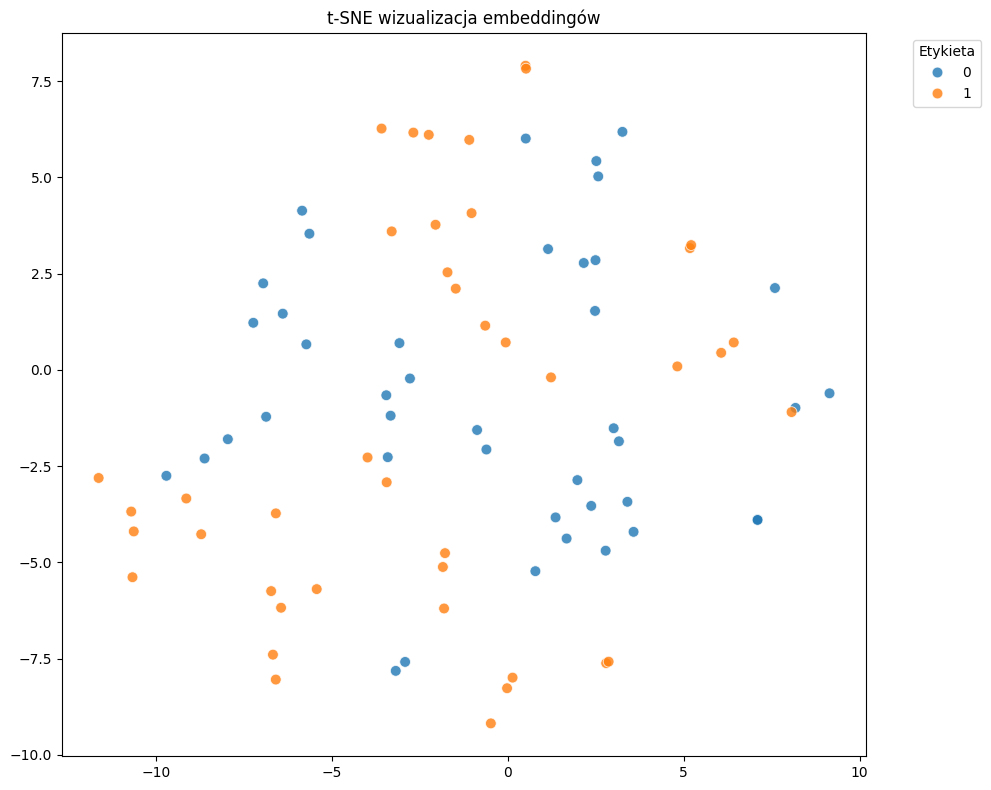

KeyboardInterrupt: 

In [127]:
test_on_n_runs(video_features, labels, 5)

In [ ]:
test_split = 0.3

features_dir = f'./deception_detection/feature_vectors_zipped/'

train_video_features, labels = get_saved_features(features_dir)

In [121]:
def get_prediction_confidence(neighbors):
    neighbors = neighbors.flatten().tolist()

    filtered = [label for label in neighbors if label != -1]
    if not filtered:
        return {"truth": 0.0, "lie": 0.0}

    counts = Counter(filtered)
    total = len(filtered)


    prob_truth = counts.get(1, 0) / total
    prob_lie = counts.get(0, 0) / total

    return {
        "truth": round(prob_truth * 100, 2),
        "lie": round(prob_lie * 100, 2)
    }

In [116]:
def predict(video_path):
  model = GRUModel(input_size=12096, hidden_size=2500, sequence_length=min_frame_size)
  model = model.to(device)
  model.load_state_dict(torch.load("./deception_detection/models/ModelGRU.pth"))

  train_loader = DataLoader(
      TensorDataset(torch.tensor(train_video_features), labels),
      batch_size=32,
      shuffle=True
  )
  prepare_and_save_features(False, video_path)
  output_dir = "./deception_detection/feature_vectors/video/"
  video_features, label= get_saved_features(output_dir, real_life=False, miami=False)
  test_loader = DataLoader(
    TensorDataset(torch.tensor(video_features), torch.tensor(label)),
    batch_size=1,
    shuffle=False
  )

  preds, neighbors = final_validate(model, train_loader, test_loader, 4, predict=True)
  prediction = "Truthful." if preds.item() == 1 else "Deceptive."
  print("Given video is " + prediction)
  print(get_prediction_confidence(neighbors))

In [122]:
predict('./trial_truth_002.mp4')

<ipython-input-116-a37ae2351841>:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  TensorDataset(torch.tensor(train_video_features), labels),
<ipython-input-116-a37ae2351841>:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  TensorDataset(torch.tensor(video_features), torch.tensor(label)),


Given video is Truthful
{'truth': 80.0, 'lie': 20.0}
